# Example: ROM for forced ball in a box simulation

### Overview

This notebook demonstrates how to build end-to-end reduced-order models (ROMs) for forced "ball in a box" simulations using the `deepe2erom` package. The workflow covers data loading, preprocessing, model construction (encoder, decoder, and dynamics), and training with the package's Trainer utility.

### Dataset

Run `data_generation.py` script to generate the high-dimensional dataset. Alternatively, download the dataset directly from [here](https://ruhr-uni-bochum.sciebo.de/s/c79mWK3NityATLT) (place the `ball_in_box_data.pkl` file in the `./data/` directory relative to this notebook).

### Expected outputs

- A trained model saved under `./results_*`
- Logs of training/validation loss and model parameter counts printed in the notebook

In [1]:
import pickle
import torch
from matplotlib.font_manager import FontProperties

# Set Times font properties for publication-quality figures
times_font_path = '/usr/share/fonts/truetype/times.ttf'
try:
    times_font = FontProperties(fname=times_font_path)
    times_font_leg = FontProperties(fname=times_font_path)
except Exception as e:
    print(f"Warning: Font not found at {times_font_path} or could not be loaded. Using default font.")
    times_font = FontProperties()
    times_font_leg = FontProperties()
times_font.set_size(8)
times_font_leg.set_size(8)

# identify device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load data
with open("./data/ball_in_box_data.pkl", "rb") as f:
    data = pickle.load(f)

# Extract data
frames, controls = data['Forced']
print("Frames shape:", frames.shape)
print("Controls shape:", controls.shape)

Using device: cuda
Frames shape: (10000, 64, 64)
Controls shape: (10000, 2)


## Data pre-processing

First, we prepare sequences for ROM training. The preprocessor converts raw frames and controls into time-series sequences suitable for for training end-to-end ROMs.

The expected input shapes for the processor are:
- for 1D states: `(nb_simulations, time_steps, states_dim)`.
- for 2D states: `(nb_simulations, time_steps, nb_channels, height, width)`.
- for controls: `(nb_simulations, time_steps, control_dim)`.

`DataPreprocessor` returns:

- processed_data[`datasets`]: dict with `train`', `val`, and `test` torch Dataset objects ready for `DataLoader`.
- processed_data[`simulations`]: dict with `train`', `val`, and `test` simulations (scaled and original).
- processed_data[`metadata`].

After processing, we typically wrap datasets in `torch.utils.data.DataLoader` with a chosen `batch_size`.

In [2]:
from deepe2erom import DataConfig, DataPreprocessor
from torch.utils.data import DataLoader
import numpy as np

# Hyperparameters
lookback = 5
pred_horizon = 1

# Configure data preprocessor
config = DataConfig(
    # Data splitting
    train_split=0.5,
    val_split=0.1,
    test_split=0.4,
    
    # Sequence parameters
    lookback=lookback,             # Use 5 past time steps as input
    pred_horizon=pred_horizon,     # Predict 1 future time step
    stride=1,                      # No skipping between sequences
    
    # Scaling
    scale_states=True,
    scale_controls=False,
    scale_states_collectively=True,         # Scale all states together (one high-dimensional field)
    scale_controls_collectively=False,      # Scale controls separately
    scaling_method="minmax",                # Scaling method: "minmax" or "standard"
    
    # Device
    device=device
)

# Initialize data preprocessor
preprocessor = DataPreprocessor(config)

# reshape data for preprocessor (nb_simulations, time_steps, nb_channels, height, width)
reshaped_frames = frames[np.newaxis, :,np.newaxis,:,:]
print("Reshaped frames shape:", reshaped_frames.shape)
# reshape controls for preprocessor (nb_simulations, time_steps, nb_control_dims)
reshaped_controls = controls[np.newaxis, :, :]
print("Reshaped controls shape:", reshaped_controls.shape)

# Process data
processed_data = preprocessor.process_simulations(states=reshaped_frames, controls=reshaped_controls)

# Extract training dataset
train_dataset = processed_data['datasets']['train']
valid_dataset = processed_data['datasets']['val']

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size)


Reshaped frames shape: (1, 10000, 1, 64, 64)
Reshaped controls shape: (1, 10000, 2)
Single simulation detected. Splitting along time axis: Train=5000, Val=1000, Test=4000 steps.
Scaling states using:  minmax


### Model creation - Control-affine

Components

- Encoder: maps high-dimensional frames to a low-dimensional latent representation.
- Decoder: reconstructs high-dimensional frames from latents.
- Dynamics (control-affine): models latent evolution using a state-dependent drift and input networks.


In [3]:
# Hyperparameters
state_dim = reshaped_frames.shape[2:]  # (nb_channels, height, width)
latent_dim = 2
control_dim = reshaped_controls.shape[-1]

encoder_arch = [
    {"type": "Conv2d", "params": {"in_channels": 1, "out_channels": 4, "kernel_size": 3, "stride": 2, "padding": 1}},
    {"type": "ReLU"},
    {"type": "Conv2d", "params": {"in_channels": 4, "out_channels": 8, "kernel_size": 3, "stride": 2, "padding": 1}},
    {"type": "ReLU"},
    {"type": "Conv2d", "params": {"in_channels": 8, "out_channels": 16, "kernel_size": 3, "stride": 2, "padding": 1}},
    {"type": "ReLU"},
    {"type": "Conv2d", "params": {"in_channels": 16, "out_channels": 32, "kernel_size": 3, "stride": 2, "padding": 1}},
    {"type": "ReLU"},
    {"type": "Flatten"},
    {"type": "Linear", "params": {"in_features": 32 * 4 * 4, "out_features": 128}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 128, "out_features": latent_dim}},
    {"type": "Sigmoid"}
]

decoder_arch = [
    {"type": "Linear", "params": {"in_features": latent_dim, "out_features": 128}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 128, "out_features": 32 * 4 * 4}},
    {"type": "Unflatten", "params": {"dim": 1, "unflattened_size": (32, 4, 4)}},
    {"type": "ConvTranspose2d", "params": {"in_channels": 32, "out_channels": 16, "kernel_size": 3, "stride": 2, "padding": 1, "output_padding": 1}},
    {"type": "ReLU"},
    {"type": "ConvTranspose2d", "params": {"in_channels": 16, "out_channels": 8, "kernel_size": 3, "stride": 2, "padding": 1, "output_padding": 1}},
    {"type": "ReLU"},
    {"type": "ConvTranspose2d", "params": {"in_channels": 8, "out_channels": 4, "kernel_size": 3, "stride": 2, "padding": 1, "output_padding": 1}},
    {"type": "ReLU"},
    {"type": "ConvTranspose2d", "params": {"in_channels": 4, "out_channels": 1, "kernel_size": 3, "stride": 2, "padding": 1, "output_padding": 1}},
    {"type": "Sigmoid"}
]

dim_dynamics = latent_dim*lookback + control_dim*(lookback-1)
drift_arch = [
    {"type": "Linear", "params": {"in_features": dim_dynamics, "out_features": 256}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 256, "out_features": 256}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 256, "out_features": 256}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 256, "out_features": latent_dim}}, 
]

input_net = [
    {"type": "Linear", "params": {"in_features": dim_dynamics, "out_features": 256}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 256, "out_features": 256}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 256, "out_features": 256}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 256, "out_features": latent_dim * control_dim}},
]

Next, we create the ROM model using the defined architectures. The `create_model` helper will wire encoder, decoder and dynamics into a single object suitable for training with the Trainer.

In [4]:
from deepe2erom import create_model

# Create model
model = create_model(
    state_dim=state_dim,
    control_dim=control_dim,
    lookback=lookback,
    pred_horizon=pred_horizon,
    latent_dim=latent_dim,
    dynamics_type="control_affine",
    encoder_arch=encoder_arch,
    decoder_arch=decoder_arch,
    drift_arch=drift_arch,
    input_arch=input_net,
    device=device,
    seed=42
)

print("Model with Linear Dynamics Created:")
print(f"  Encoder: {model.encoder}")
print(f"  Decoder: {model.decoder}")
print(f"  Dynamics: {model.dynamics}")
print(f"  Device: {model.config.device}")

# parameter count
param_counts = model.count_parameters(verbose=True)

Model with Linear Dynamics Created:
  Encoder: Sequential(
  (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (1): ReLU()
  (2): Conv2d(4, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (3): ReLU()
  (4): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (5): ReLU()
  (6): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (7): ReLU()
  (8): Flatten(start_dim=1, end_dim=-1)
  (9): Linear(in_features=512, out_features=128, bias=True)
  (10): ReLU()
  (11): Linear(in_features=128, out_features=2, bias=True)
  (12): Sigmoid()
)
  Decoder: Sequential(
  (0): Linear(in_features=2, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=512, bias=True)
  (3): Unflatten(dim=1, unflattened_size=(32, 4, 4))
  (4): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (5): ReLU()
  (6): ConvTranspose2d(16, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 

### Training Control-affine ROM

Training workflow

1. Create a `Trainer` with appropriate weights for reconstruction, prediction, and latent consistency.
2. Run `Trainer.train` which performs optional AE pretraining followed by full training of the ROM.

The `save_path` directory will contain model checkpoints and any saved logs.


In [11]:
from deepe2erom import Trainer

# Initialize Trainer
trainer = Trainer(
    model=model,
    rec_weight=1.0,           # Weight for state reconstruction
    pred_weight=0.3,          # Weight for future prediction
    latent_weight=1.0,        # Weight for latent space consistency
    learning_rate=1e-3,       # Learning rate
    restarts_ae=5,           # Number of training restarts for autoencoders (pre-training phase)
    restarts_e2e=5,           # Number of end-to-end training restarts
    device=device
)

# Train the model
save_dir = "./results_control_affine"

best_loss = trainer.train(
    train_loader=train_loader,
    valid_data=valid_loader,
    epochs=500,                          # Maximum epochs for full training
    ae_epochs=20,                        # Pre-train autoencoders for 20 epochs                     
    patience_early_stopping=30,          
    patience_lr_scheduler=15,            
    save_path=save_dir,
    seed=42
)

print(f"Training finished. Best validation loss: {best_loss:.6f}")

  AE Restart 1/5
    Training States Autoencoder for 20 epochs...
Epoch 1 - New best state AE validation loss: 0.032549
Epoch 2 - New best state AE validation loss: 0.024407
Epoch 3 - New best state AE validation loss: 0.022707
Epoch 4 - New best state AE validation loss: 0.022362
Epoch 5 - New best state AE validation loss: 0.022123
Epoch 8 - New best state AE validation loss: 0.022034
Epoch 9 - New best state AE validation loss: 0.021929
Epoch 13 - New best state AE validation loss: 0.021856
  AE Restart 2/5
    Training States Autoencoder for 20 epochs...
  AE Restart 3/5
    Training States Autoencoder for 20 epochs...
Epoch 3 - New best state AE validation loss: 0.021684
Epoch 4 - New best state AE validation loss: 0.007580
Epoch 5 - New best state AE validation loss: 0.004592
Epoch 6 - New best state AE validation loss: 0.003338
Epoch 7 - New best state AE validation loss: 0.002724
Epoch 8 - New best state AE validation loss: 0.002485
Epoch 9 - New best state AE validation loss: 

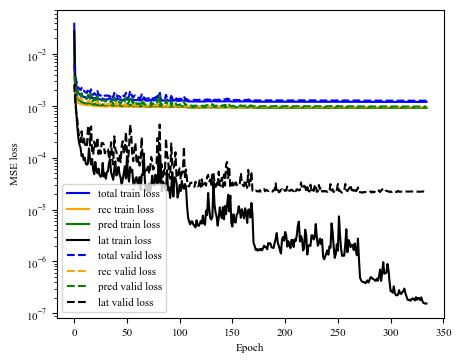

In [5]:
import pickle
import os
import matplotlib.pyplot as plt

# Load history
save_dir = "./results_control_affine"
history_path = os.path.join(save_dir, "history.pkl")
with open(history_path, "rb") as f:
    history = pickle.load(f)

# Plot Learning Curves
fig, axs = plt.subplots(figsize=(5, 4))
axs.set_yscale('log')
axs.set_xlabel('Epoch', fontproperties=times_font)
axs.set_ylabel('MSE loss', fontproperties=times_font)
axs.plot(history['avg_epoch_total_loss_train'], color='blue', linestyle='-', label='total train loss')
axs.plot(history['avg_epoch_rec_loss_train'], color='orange', linestyle='-', label='rec train loss')
axs.plot(history['avg_epoch_pred_loss_train'], color='green', linestyle='-', label='pred train loss')
axs.plot(history['avg_epoch_lat_loss_train'], color='black', linestyle='-', label='lat train loss')

axs.plot(history['epoch_total_loss_valid'], color='blue', linestyle='--', label='total valid loss')
axs.plot(history['epoch_rec_loss_valid'], color='orange', linestyle='--', label='rec valid loss')
axs.plot(history['epoch_pred_loss_valid'], color='green', linestyle='--', label='pred valid loss')
axs.plot(history['epoch_lat_loss_valid'], color='black', linestyle='--', label='lat valid loss')
for label in axs.get_xticklabels():
    label.set_fontproperties(times_font)
for label in axs.get_yticklabels():
    label.set_fontproperties(times_font)
axs.legend(prop=times_font_leg)

### Model Evaluation - Control-affine

To evaluate the trained model, we perform a long-term simulation using initial conditions from the test dataset.

- We select a random trajectory from the test set and extract the initial sequence of states ($X_0$) and the corresponding sequence of control inputs ($U$).
- The model autoregressively predicts future states based on the initial conditions and controls.

In [6]:
# load the model
model.load_state_dict(torch.load('./results_control_affine/best_model.pth'))

# Evaluate a test simulation
sim_idx = 0
sim_length = 500
init_idx = 123 # randomly chosen initial conditions
test_sim = processed_data['simulations']['test'][0]

# get initial conditions and controls
X0 = test_sim.states_scaled[sim_idx, init_idx:init_idx+lookback]
U = test_sim.controls[sim_idx, init_idx:]

# ground truth states
true_states = test_sim.states_scaled[sim_idx, init_idx+lookback:init_idx+lookback+sim_length].cpu()
print("True states shape:", true_states.shape)

# simulate 
pred_latents, pred_states = model.simulate(X0, U, sim_length) # Input sequences should not be batched

True states shape: torch.Size([500, 1, 64, 64])


We evalute first the end-to-predicitons of the model:

RMSE: 0.033246


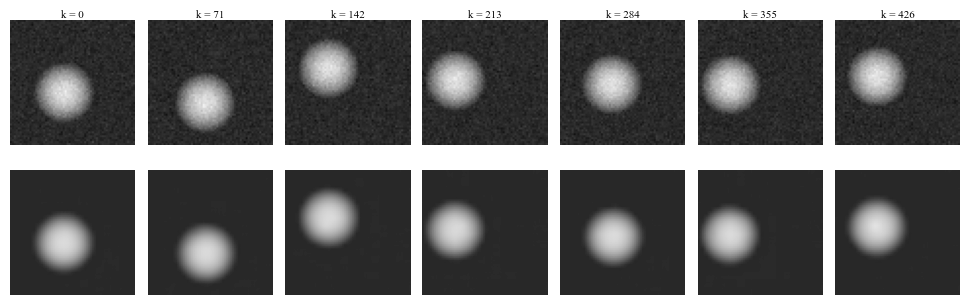

Comparison 2D animation saved to: ./results_control_affine/e2e_comparison.gif


In [14]:
from deepe2erom import animate_compare_2Dsimulations

# Compute RMSE between ground_truth and predicted_dynamics
with torch.no_grad():                                                      # (T-seq, H, W)
    rmse = torch.sqrt(torch.mean((true_states - pred_states) ** 2)).item()
print(f"RMSE: {rmse:.6f}")

# Plot multiple timesteps as subplots
num_timesteps = 7
fig, axs = plt.subplots(2, num_timesteps, figsize=(9.5, 3), gridspec_kw={'wspace': 0.1, 'hspace': 0.0})
step_size = pred_states.shape[0] // num_timesteps
axs = np.atleast_1d(axs) # type: ignore
for t in range(num_timesteps):
    timestep = t * step_size
    axs[0, t].imshow(true_states[timestep,0], cmap='gray', vmin=0, vmax=1)
    axs[0, t].set_title(r"k = {}".format(timestep), fontproperties=times_font, pad=1)
    axs[0, t].axis('off')
    axs[1, t].imshow(pred_states[timestep, 0].detach(), cmap='gray', vmin=0, vmax=1)
    axs[1, t].axis('off')
plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)
fig.savefig("./results_control_affine/state_reconstruction_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

# save animation
animate_compare_2Dsimulations(
    true_states,
    pred_states,
    save_path="./results_control_affine/e2e_comparison.gif",
    cmap='gray',
)

Next, we evaluate the control-affine latent dynamics. We consider another trajectory as the one shown above:

True states shape: torch.Size([700, 1, 64, 64])

Latent RMSE (overall): 0.018232
Latent RMSE per-dim: 0.020704, 0.015368


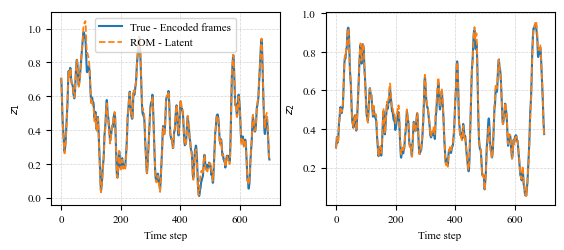

In [7]:
# Evaluate a test simulation
sim_idx = 0
sim_length = 700
init_idx = 1234 # randomly chosen initial conditions
test_sim = processed_data['simulations']['test'][0]

# get initial conditions and controls
X0 = test_sim.states_scaled[sim_idx, init_idx:init_idx+lookback]
U = test_sim.controls[sim_idx, init_idx:]

# ground truth states
true_states = test_sim.states_scaled[sim_idx, init_idx+lookback:init_idx+lookback+sim_length]
print("True states shape:", true_states.shape)

# simulate 
pred_latents, pred_states = model.simulate(X0, U, sim_length) # Input sequences should not be batched

# Get the true latents
model.eval()
with torch.no_grad():
    true_latents = model.encoder(true_states).cpu() # input shape for the encoder (*, nb_channels, height, width)


# Plot latent dynamics comparison
fig, axs = plt.subplots(1, latent_dim, figsize=(6.5, 2.5))
axs = np.atleast_1d(axs) # type: ignore
axs[0].plot(true_latents[:, 0], color='C0')
axs[0].plot(pred_latents[:, 0], linestyle='--', color='C1', linewidth=1.25)
axs[0].set_ylabel(r"$z_1$", fontproperties=times_font)
axs[0].set_xlabel('Time step', fontproperties=times_font)
axs[0].legend(['True - Encoded frames', 'ROM - Latent'], prop=times_font_leg)
axs[0].grid(color='lightgray', linestyle='--', linewidth=0.5)
axs[1].plot(true_latents[:, 1], color='C0')
axs[1].plot(pred_latents[:, 1], linestyle='--', color='C1', linewidth=1.25)
axs[1].set_ylabel(r"$z_2$", fontproperties=times_font)
axs[1].set_xlabel('Time step', fontproperties=times_font)
axs[1].grid(color='lightgray', linestyle='--', linewidth=0.5)
for label in axs[0].get_xticklabels() + axs[0].get_yticklabels() + axs[1].get_xticklabels() + axs[1].get_yticklabels():
    label.set_fontproperties(times_font)
fig.savefig("./results_control_affine/latent_dynamics_comparison.pdf", dpi=300, bbox_inches='tight')
# Compute RMSE
with torch.no_grad():
    diff = pred_latents - true_latents
    latent_rmse_overall = torch.sqrt(torch.mean(diff ** 2)).item()
    latent_rmse_per_dim = torch.sqrt(torch.mean(diff ** 2, dim=0)).detach().cpu()
print(f"\nLatent RMSE (overall): {latent_rmse_overall:.6f}")
print("Latent RMSE per-dim: " + ", ".join([f"{v:.6f}" for v in latent_rmse_per_dim]))



### Autonomous predictions - Control-affine

We assess the performance of the model in predicting autonomous trajectories. Note that the model has been trained using only forced trajectories.

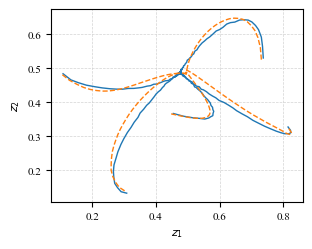

In [8]:
autonom_trajectories = data['Autonomous']
# add channel dimesion
autonom_trajectories = autonom_trajectories[:, :, np.newaxis, :, :]

# scale 
autonom_trajectories_scaled = preprocessor.scale_trajectories(autonom_trajectories)

# Evaluate a test simulation
sim_idx = [89, 432, 12, 221, 445]
sim_length = 75
fig, axs = plt.subplots(figsize=(3.25, 2.5))
for idx in sim_idx:
    sim_idx = idx
    X0 = autonom_trajectories_scaled[sim_idx, :lookback]
    U = torch.zeros((lookback+sim_length-1, control_dim))  # No control inputs

    # simulate 
    pred_latents, pred_states = model.simulate(X0, U, sim_length)

    # ground truth states
    true_states = autonom_trajectories_scaled[sim_idx, lookback:lookback+sim_length]
    # ground truth latents
    model.eval()
    with torch.no_grad():
        true_latents = model.encoder(torch.tensor(true_states, dtype=torch.float32, device=device)).cpu()

    # Plot latent dynamics comparison
    axs.plot(true_latents[:, 0], true_latents[:, 1],color='C0', linestyle='-', linewidth=1)
    axs.plot(pred_latents[:, 0], pred_latents[:, 1],color='C1', linestyle='--', linewidth=1)
    axs.set_xlabel(r"$z_1$", fontproperties=times_font)
    axs.set_ylabel(r"$z_2$", fontproperties=times_font)
    axs.grid(color='lightgray', linestyle='--', linewidth=0.5)
    for label in axs.get_xticklabels() + axs.get_yticklabels():
        label.set_fontproperties(times_font)
fig.savefig("./results_control_affine/latent_autonomous_comparison.pdf", dpi=300, bbox_inches='tight')


To further evaluate the autonomous dynamics, we identify the latent equilibrium of the trained drift network and compare it to the encoded physical equilibrium $\mathbf{z}^*=\mathcal{E}_\theta(\mathbf{x}^*)$, where $\mathbf{x}^*$ denotes the equilibrium frame, corresponding to the ball being at the center of the box. For this, we solve a fixed-point problem in the latent space.

In [38]:
# define the latent vector as optimization variable
z_eq = torch.empty((1, latent_dim), device=device)
U = torch.zeros((1, lookback, control_dim), device=device)
# initialize
z_eq.data[0][0] = 1.0
z_eq.data[0][1] = 1.0
# make it trainable
z_eq.requires_grad_(True)

# define the optimizer
optimizer = torch.optim.Adam([z_eq], lr=1e-2)

max_iter = 10000
tol = 1e-7

for iter in range(max_iter):
    optimizer.zero_grad()
    # reshape the signal
    z_input = z_eq.repeat(1, lookback, 1)
    # forward pass 
    u_window = U[:, :lookback, :]
    # compute the drift
    z_next = model.dynamics(z_input, u_window) # type: ignore
    
    # compute the loss
    loss = torch.mean((z_next - z_eq) ** 2)

    # save the value with the smallest loss
    if iter == 0:
        z_best = z_eq.detach().clone()
        loss_best = loss.item()
    elif loss.item() < loss_best:
        z_best = z_eq.detach().clone()
        loss_best = loss.item()

    # Backpropagate
    loss.backward()

    # print the loss 
    if (iter+1) % 100 == 0:
        print(f"Iteration {iter+1}, loss: {loss.item()}")
    
    # Update x
    optimizer.step()

    # Check convergence
    if loss.item() < tol:
        #print(f"Equilibrium found at: {z_eq.detach().cpu().numpy()}")
        break

# encoded latent equilibrium
initial_frame = processed_data['simulations']['train'][0].states_scaled[0,0:1]
z_eq_encoded = model.encoder(initial_frame.to(device))

print("\n" + "="*40)
print("Comparison of latent equilibrium states:")
print("="*40)
print(f"Encoded latent from initial frame: {z_eq_encoded.detach().cpu().numpy()}")
print(f"Optimized latent equilibrium: {z_best.detach().cpu().numpy()}")
print("="*40)

Iteration 100, loss: 1.0339626896893606e-05
Iteration 200, loss: 1.4496214362225146e-07

Comparison of latent equilibrium states:
Encoded latent from initial frame: [[0.47487512 0.4861413 ]]
Optimized latent equilibrium: [[0.50289094 0.48877442]]


### Comparison with linear latent dynamics

We train a baseline ROM, where we maintain the same architecture for the autoencoder and constraint the dynamics within the latent space to a linear model. 

In [40]:
from deepe2erom import Trainer

# Create model with linear dynamics
model_linear = create_model(
    state_dim=state_dim,
    control_dim=control_dim,
    lookback=lookback,
    pred_horizon=pred_horizon,
    latent_dim=latent_dim,
    dynamics_type="linear",
    encoder_arch=encoder_arch,
    decoder_arch=decoder_arch,
    device=device,
    seed=42
)

print("Model with Linear Dynamics Created:")
print(model_linear)

Model with Linear Dynamics Created:
DeepE2EROM(
  (encoder): Sequential(
    (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(4, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=512, out_features=128, bias=True)
    (10): ReLU()
    (11): Linear(in_features=128, out_features=2, bias=True)
    (12): Sigmoid()
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=512, bias=True)
    (3): Unflatten(dim=1, unflattened_size=(32, 4, 4))
    (4): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspos

Training loop:

In [41]:
# Initialize Trainer
trainer_linear = Trainer(
    model=model_linear,
    rec_weight=1.0,           # Weight for state reconstruction
    pred_weight=0.3,          # Weight for future prediction
    latent_weight=1.0,        # Weight for latent space consistency
    learning_rate=1e-2,       # Learning rate
    restarts_ae=5,           # Number of training restarts for autoencoders (pre-training phase)
    restarts_e2e=5,           # Number of end-to-end training restarts
    device=device
)

# Train the model
save_dir = "./results_baseline"

best_loss = trainer_linear.train(
    train_loader=train_loader,
    valid_data=valid_loader,
    epochs=500,                          # Maximum epochs for full training
    ae_epochs=20,                        # Pre-train autoencoders for 10 epochs                     
    patience_early_stopping=30,          
    patience_lr_scheduler=15,            
    save_path=save_dir,
    seed=42
)

print(f"Training finished. Best validation loss: {best_loss:.6f}")

  AE Restart 1/5
    Training States Autoencoder for 20 epochs...
Epoch 1 - New best state AE validation loss: 0.022406
Epoch 3 - New best state AE validation loss: 0.022363
Epoch 4 - New best state AE validation loss: 0.022130
Epoch 5 - New best state AE validation loss: 0.021933
Epoch 9 - New best state AE validation loss: 0.021914
Epoch 12 - New best state AE validation loss: 0.021903
Epoch 13 - New best state AE validation loss: 0.021816
  AE Restart 2/5
    Training States Autoencoder for 20 epochs...
  AE Restart 3/5
    Training States Autoencoder for 20 epochs...
Epoch 5 - New best state AE validation loss: 0.021757
Epoch 6 - New best state AE validation loss: 0.016721
Epoch 7 - New best state AE validation loss: 0.014529
Epoch 8 - New best state AE validation loss: 0.006952
Epoch 9 - New best state AE validation loss: 0.004107
Epoch 10 - New best state AE validation loss: 0.002774
Epoch 11 - New best state AE validation loss: 0.002471
Epoch 12 - New best state AE validation lo

### Evaluation of Baseline ROM

True states shape: torch.Size([500, 1, 64, 64])
RMSE: 0.051960


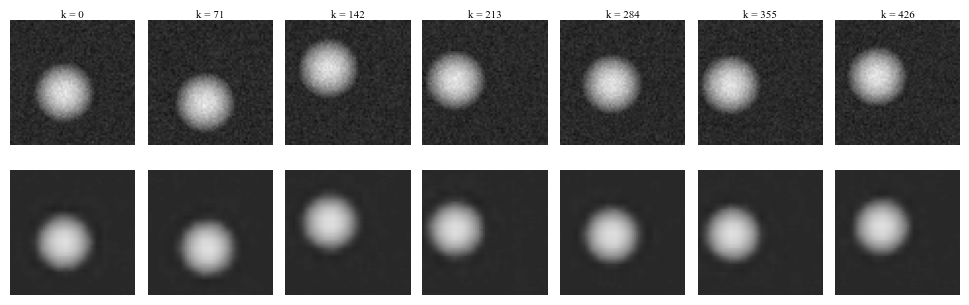

True states shape: torch.Size([700, 1, 64, 64])

Latent RMSE (overall): 0.068704
Latent RMSE per-dim: 0.074167, 0.062766


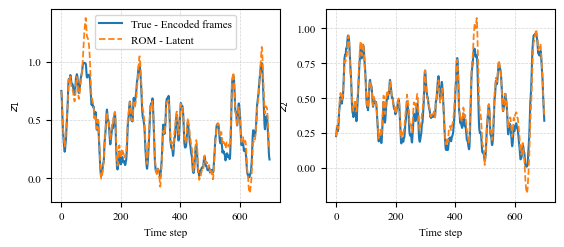

In [42]:
# load the model
model_linear.load_state_dict(torch.load('./results_baseline/best_model.pth'))

# Evaluate a test simulation
sim_idx = 0
sim_length = 500
init_idx = 123 # randomly chosen initial conditions
test_sim = processed_data['simulations']['test'][0]

# get initial conditions and controls
X0 = test_sim.states_scaled[sim_idx, init_idx:init_idx+lookback]
U = test_sim.controls[sim_idx, init_idx:]

# ground truth states
true_states = test_sim.states_scaled[sim_idx, init_idx+lookback:init_idx+lookback+sim_length].cpu()
print("True states shape:", true_states.shape)

# simulate 
pred_latents, pred_states = model_linear.simulate(X0, U, sim_length) # Input sequences should not be batched

# Compute RMSE between ground_truth and predicted_dynamics (exclude the first seq_length seeded steps)
with torch.no_grad():                                                      # (T-seq, H, W)
    rmse = torch.sqrt(torch.mean((true_states - pred_states) ** 2)).item()
print(f"RMSE: {rmse:.6f}")

# Plot multiple timesteps as subplots
num_timesteps = 7
fig, axs = plt.subplots(2, num_timesteps, figsize=(9.5, 3), gridspec_kw={'wspace': 0.1, 'hspace': 0.0})
step_size = pred_states.shape[0] // num_timesteps
axs = np.atleast_1d(axs) # type: ignore
for t in range(num_timesteps):
    timestep = t * step_size
    axs[0, t].imshow(true_states[timestep,0], cmap='gray', vmin=0, vmax=1)
    axs[0, t].set_title(r"k = {}".format(timestep), fontproperties=times_font, pad=1)
    axs[0, t].axis('off')
    axs[1, t].imshow(pred_states[timestep, 0].detach(), cmap='gray', vmin=0, vmax=1)
    axs[1, t].axis('off')
plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)
fig.savefig("./results_baseline/state_reconstruction_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Evaluate a test simulation
sim_idx = 0
sim_length = 700
init_idx = 1234 # randomly chosen initial conditions
test_sim = processed_data['simulations']['test'][0]

# get initial conditions and controls
X0 = test_sim.states_scaled[sim_idx, init_idx:init_idx+lookback]
U = test_sim.controls[sim_idx, init_idx:]

# ground truth states
true_states = test_sim.states_scaled[sim_idx, init_idx+lookback:init_idx+lookback+sim_length]
print("True states shape:", true_states.shape)

# simulate 
pred_latents, pred_states = model_linear.simulate(X0, U, sim_length) # Input sequences should not be batched

# Get the true latents
model_linear.eval()
with torch.no_grad():
    true_latents = model_linear.encoder(true_states).cpu() # input shape for the encoder (*, nb_channels, height, width)


# Plot latent dynamics comparison
fig, axs = plt.subplots(1, latent_dim, figsize=(6.5, 2.5))
axs = np.atleast_1d(axs) # type: ignore
axs[0].plot(true_latents[:, 0], color='C0')
axs[0].plot(pred_latents[:, 0], linestyle='--', color='C1', linewidth=1.25)
axs[0].set_ylabel(r"$z_1$", fontproperties=times_font)
axs[0].set_xlabel('Time step', fontproperties=times_font)
axs[0].legend(['True - Encoded frames', 'ROM - Latent'], prop=times_font_leg)
axs[0].grid(color='lightgray', linestyle='--', linewidth=0.5)
axs[1].plot(true_latents[:, 1], color='C0')
axs[1].plot(pred_latents[:, 1], linestyle='--', color='C1', linewidth=1.25)
axs[1].set_ylabel(r"$z_2$", fontproperties=times_font)
axs[1].set_xlabel('Time step', fontproperties=times_font)
axs[1].grid(color='lightgray', linestyle='--', linewidth=0.5)
for label in axs[0].get_xticklabels() + axs[0].get_yticklabels() + axs[1].get_xticklabels() + axs[1].get_yticklabels():
    label.set_fontproperties(times_font)
fig.savefig("./results_baseline/latent_dynamics_comparison.pdf", dpi=300, bbox_inches='tight')
# Compute RMSE
with torch.no_grad():
    diff = pred_latents - true_latents
    latent_rmse_overall = torch.sqrt(torch.mean(diff ** 2)).item()
    latent_rmse_per_dim = torch.sqrt(torch.mean(diff ** 2, dim=0)).detach().cpu()
print(f"\nLatent RMSE (overall): {latent_rmse_overall:.6f}")
print("Latent RMSE per-dim: " + ", ".join([f"{v:.6f}" for v in latent_rmse_per_dim]))


### Comparison with nonliear latent dynamics (LSTM)

Here, we maintain the same architecture for the autoencoder and consider a general nonlinear latent dynamics modeled using LSTM network. 

In [52]:
# Create model
model_lstm = create_model(
    state_dim=state_dim,
    control_dim=control_dim,
    lookback=lookback,
    pred_horizon=pred_horizon,
    latent_dim=latent_dim,
    dynamics_type="lstm",
    encoder_arch=encoder_arch,
    decoder_arch=decoder_arch,
    lstm_hidden_size=250,
    device=device,
    seed=42
)

print("Model with LSTM Dynamics Created:")
print(model_lstm)

Model with LSTM Dynamics Created:
DeepE2EROM(
  (encoder): Sequential(
    (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(4, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=512, out_features=128, bias=True)
    (10): ReLU()
    (11): Linear(in_features=128, out_features=2, bias=True)
    (12): Sigmoid()
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=512, bias=True)
    (3): Unflatten(dim=1, unflattened_size=(32, 4, 4))
    (4): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2

Trainin loop:

In [53]:
# Initialize Trainer
trainer_lstm = Trainer(
    model=model_lstm,
    rec_weight=1.0,           # Weight for state reconstruction
    pred_weight=0.3,          # Weight for future prediction
    latent_weight=1.0,        # Weight for latent space consistency
    learning_rate=1e-2,       # Learning rate
    restarts_ae=5,           # Number of training restarts for autoencoders (pre-training phase)
    restarts_e2e=5,           # Number of end-to-end training restarts
    device=device
)

# Train the model
save_dir = "./results_lstm"

best_loss = trainer_lstm.train(
    train_loader=train_loader,
    valid_data=valid_loader,
    epochs=500,                          # Maximum epochs for full training
    ae_epochs=20,                        # Pre-train autoencoders for 10 epochs                     
    patience_early_stopping=30,          
    patience_lr_scheduler=15,            
    save_path=save_dir,
    seed=42
)

print(f"Training finished. Best validation loss: {best_loss:.6f}")

  AE Restart 1/5
    Training States Autoencoder for 20 epochs...
Epoch 1 - New best state AE validation loss: 0.022320
Epoch 3 - New best state AE validation loss: 0.022216
Epoch 4 - New best state AE validation loss: 0.021970
Epoch 5 - New best state AE validation loss: 0.021868
Epoch 13 - New best state AE validation loss: 0.021858
Epoch 17 - New best state AE validation loss: 0.021846
  AE Restart 2/5
    Training States Autoencoder for 20 epochs...
  AE Restart 3/5
    Training States Autoencoder for 20 epochs...
Epoch 5 - New best state AE validation loss: 0.021755
Epoch 6 - New best state AE validation loss: 0.019552
Epoch 7 - New best state AE validation loss: 0.007670
Epoch 8 - New best state AE validation loss: 0.004971
Epoch 9 - New best state AE validation loss: 0.003898
Epoch 10 - New best state AE validation loss: 0.003095
Epoch 11 - New best state AE validation loss: 0.002662
Epoch 12 - New best state AE validation loss: 0.002096
Epoch 13 - New best state AE validation l

### Evaluation of LSTM ROM

True states shape: torch.Size([500, 1, 64, 64])
RMSE: 0.032706


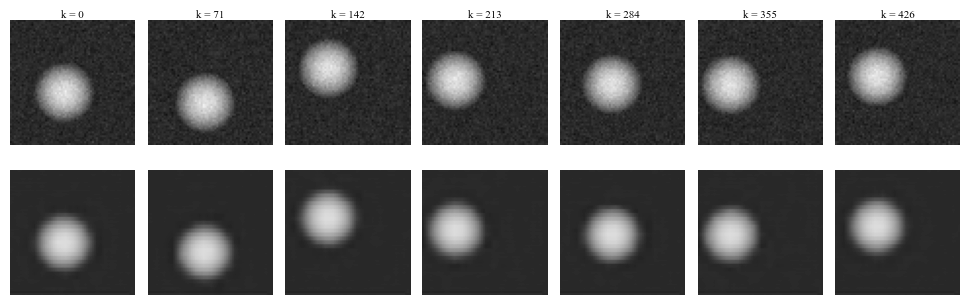

True states shape: torch.Size([700, 1, 64, 64])

Latent RMSE (overall): 0.008555
Latent RMSE per-dim: 0.010165, 0.006561


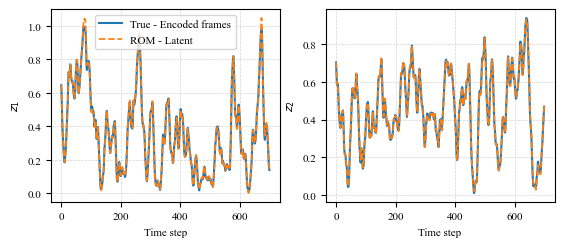

In [54]:
# load the model
model_lstm.load_state_dict(torch.load('./results_lstm/best_model.pth'))

# Evaluate a test simulation
sim_idx = 0
sim_length = 500
init_idx = 123 # randomly chosen initial conditions
test_sim = processed_data['simulations']['test'][0]

# get initial conditions and controls
X0 = test_sim.states_scaled[sim_idx, init_idx:init_idx+lookback]
U = test_sim.controls[sim_idx, init_idx:]

# ground truth states
true_states = test_sim.states_scaled[sim_idx, init_idx+lookback:init_idx+lookback+sim_length].cpu()
print("True states shape:", true_states.shape)

# simulate 
pred_latents, pred_states = model_lstm.simulate(X0, U, sim_length) # Input sequences should not be batched

# Compute RMSE between ground_truth and predicted_dynamics (exclude the first seq_length seeded steps)
with torch.no_grad():                                                      # (T-seq, H, W)
    rmse = torch.sqrt(torch.mean((true_states - pred_states) ** 2)).item()
print(f"RMSE: {rmse:.6f}")

# Plot multiple timesteps as subplots
num_timesteps = 7
fig, axs = plt.subplots(2, num_timesteps, figsize=(9.5, 3), gridspec_kw={'wspace': 0.1, 'hspace': 0.0})
step_size = pred_states.shape[0] // num_timesteps
axs = np.atleast_1d(axs) # type: ignore
for t in range(num_timesteps):
    timestep = t * step_size
    axs[0, t].imshow(true_states[timestep,0], cmap='gray', vmin=0, vmax=1)
    axs[0, t].set_title(r"k = {}".format(timestep), fontproperties=times_font, pad=1)
    axs[0, t].axis('off')
    axs[1, t].imshow(pred_states[timestep, 0].detach(), cmap='gray', vmin=0, vmax=1)
    axs[1, t].axis('off')
plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)
fig.savefig("./results_lstm/state_reconstruction_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Evaluate a test simulation
sim_idx = 0
sim_length = 700
init_idx = 1234 # randomly chosen initial conditions
test_sim = processed_data['simulations']['test'][0]

# get initial conditions and controls
X0 = test_sim.states_scaled[sim_idx, init_idx:init_idx+lookback]
U = test_sim.controls[sim_idx, init_idx:]

# ground truth states
true_states = test_sim.states_scaled[sim_idx, init_idx+lookback:init_idx+lookback+sim_length]
print("True states shape:", true_states.shape)

# simulate 
pred_latents, pred_states = model_lstm.simulate(X0, U, sim_length) # Input sequences should not be batched

# Get the true latents
model_lstm.eval()
with torch.no_grad():
    true_latents = model_lstm.encoder(true_states).cpu() # input shape for the encoder (*, nb_channels, height, width)


# Plot latent dynamics comparison
fig, axs = plt.subplots(1, latent_dim, figsize=(6.5, 2.5))
axs = np.atleast_1d(axs) # type: ignore
axs[0].plot(true_latents[:, 0], color='C0')
axs[0].plot(pred_latents[:, 0], linestyle='--', color='C1', linewidth=1.25)
axs[0].set_ylabel(r"$z_1$", fontproperties=times_font)
axs[0].set_xlabel('Time step', fontproperties=times_font)
axs[0].legend(['True - Encoded frames', 'ROM - Latent'], prop=times_font_leg)
axs[0].grid(color='lightgray', linestyle='--', linewidth=0.5)
axs[1].plot(true_latents[:, 1], color='C0')
axs[1].plot(pred_latents[:, 1], linestyle='--', color='C1', linewidth=1.25)
axs[1].set_ylabel(r"$z_2$", fontproperties=times_font)
axs[1].set_xlabel('Time step', fontproperties=times_font)
axs[1].grid(color='lightgray', linestyle='--', linewidth=0.5)
for label in axs[0].get_xticklabels() + axs[0].get_yticklabels() + axs[1].get_xticklabels() + axs[1].get_yticklabels():
    label.set_fontproperties(times_font)
fig.savefig("./results_lstm/latent_dynamics_comparison.pdf", dpi=300, bbox_inches='tight')
# Compute RMSE
with torch.no_grad():
    diff = pred_latents - true_latents
    latent_rmse_overall = torch.sqrt(torch.mean(diff ** 2)).item()
    latent_rmse_per_dim = torch.sqrt(torch.mean(diff ** 2, dim=0)).detach().cpu()
print(f"\nLatent RMSE (overall): {latent_rmse_overall:.6f}")
print("Latent RMSE per-dim: " + ", ".join([f"{v:.6f}" for v in latent_rmse_per_dim]))


### Comparison of ROMs (Average error over 100 simulations)

#### End-to-end and latent errors:

In [56]:
import numpy as np

# Configuration
n_sims = 100
sim_len = 500
lookback = model.config.lookback

# Storage for errors
errors_affine_states = []
errors_linear_states = []
errors_lstm_states = []
errors_affine_latents = []
errors_linear_latents = []
errors_lstm_latents = []

# Get test data
test_data = processed_data['simulations']['test'][0]
n_test_trajs = test_data.states_scaled.shape[0]
traj_len = test_data.states_scaled.shape[1]

print(f"Computing average RMSE over {n_sims} simulations of length {sim_len}...")

for i in range(n_sims):
    # Random selection (seed for reproducibility)
    np.random.seed(i)
    sim_idx = np.random.randint(0, n_test_trajs)
    # Ensure valid range for simulation
    max_idx = traj_len - lookback - sim_len
    init_idx = np.random.randint(0, max_idx)
    
    # Inputs
    X0 = test_data.states_scaled[sim_idx, init_idx:init_idx+lookback]
    U = test_data.controls[sim_idx, init_idx:]
    
    # Ground truth
    true_states = test_data.states_scaled[sim_idx, init_idx+lookback:init_idx+lookback+sim_len].cpu()
    
    # Simulate Control-Affine
    pred_latents_aff, pred_states_aff = model.simulate(X0, U, sim_len)
    rmse_aff_states = torch.sqrt(torch.mean((true_states - pred_states_aff)**2)).item()
    rmse_aff_latents = torch.sqrt(torch.mean((model.encoder(true_states.to(device)).cpu() - pred_latents_aff)**2)).item()
    errors_affine_latents.append(rmse_aff_latents)
    errors_affine_states.append(rmse_aff_states)
    
    # Simulate Linear
    pred_latents_lin, pred_states_lin = model_linear.simulate(X0, U, sim_len)
    rmse_lin_states = torch.sqrt(torch.mean((true_states - pred_states_lin)**2)).item()
    rmse_lin_latents = torch.sqrt(torch.mean((model_linear.encoder(true_states.to(device)).cpu() - pred_latents_lin)**2)).item()
    errors_linear_latents.append(rmse_lin_latents)
    errors_linear_states.append(rmse_lin_states)

    # Simulate LSTM
    pred_latents_lstm, pred_states_lstm = model_lstm.simulate(X0, U, sim_len)
    rmse_lstm_states = torch.sqrt(torch.mean((true_states - pred_states_lstm)**2)).item()
    rmse_lstm_latents = torch.sqrt(torch.mean((model_lstm.encoder(true_states.to(device)).cpu() - pred_latents_lstm)**2)).item()
    errors_lstm_latents.append(rmse_lstm_latents)
    errors_lstm_states.append(rmse_lstm_states)

# Statistics
mean_aff_states = np.mean(errors_affine_states)
std_aff_states = np.std(errors_affine_states)
mean_lin_states = np.mean(errors_linear_states)
std_lin_states = np.std(errors_linear_states)

mean_aff_latents = np.mean(errors_affine_latents)
std_aff_latents = np.std(errors_affine_latents)
mean_lin_latents = np.mean(errors_linear_latents)
std_lin_latents = np.std(errors_linear_latents)

mean_lstm_states = np.mean(errors_lstm_states)
std_lstm_states = np.std(errors_lstm_states)
mean_lstm_latents = np.mean(errors_lstm_latents)
std_lstm_latents = np.std(errors_lstm_latents)

print("\n" + "="*40)
print("COMPARISON RESULTS (End-to-End) OVER 100 SIMULATIONS")
print("="*40)
print(f"Control-Affine ROM: {mean_aff_states:.6f} ± {std_aff_states:.6f}")
print(f"Linear Baseline:    {mean_lin_states:.6f} ± {std_lin_states:.6f}")
print(f"LSTM:               {mean_lstm_states:.6f} ± {std_lstm_states:.6f}")
print("="*40)

print("\n" + "="*40)
print("COMPARISON RESULTS (latents) OVER 100 SIMULATIONS")
print("="*40)
print(f"Control-Affine ROM: {mean_aff_latents:.6f} ± {std_aff_latents:.6f}")
print(f"Linear Baseline:    {mean_lin_latents:.6f} ± {std_lin_latents:.6f}")
print(f"LSTM:               {mean_lstm_latents:.6f} ± {std_lstm_latents:.6f}")
print("="*40)


COMPARISON RESULTS (End-to-End) OVER 100 SIMULATIONS
Control-Affine ROM: 0.034748 ± 0.001422
Linear Baseline:    0.060397 ± 0.006426
LSTM:               0.033112 ± 0.000361

COMPARISON RESULTS (latents) OVER 100 SIMULATIONS
Control-Affine ROM: 0.015739 ± 0.002885
Linear Baseline:    0.056243 ± 0.011211
LSTM:               0.008515 ± 0.001749


#### Autonomous errors:

In [57]:
# Configuration
n_sims = 100
sim_len = 75
lookback = model.config.lookback

# Storage for errors
errors_affine_states_auto = []
errors_linear_states_auto = []
errors_affine_latents_auto = []
errors_linear_latents_auto = []
errors_lstm_states_auto = []
errors_lstm_latents_auto = []

# Get autonomous data (already scaled in previous cells)
n_auto_trajs = autonom_trajectories_scaled.shape[0]
traj_len = autonom_trajectories_scaled.shape[1]

print(f"Computing average RMSE over {n_sims} autonomous simulations of length {sim_len}...")

for i in range(n_sims):
    # Random selection (seed for reproducibility)
    np.random.seed(i+100)
    sim_idx = np.random.randint(0, n_auto_trajs)
    
    # Ensure valid range for simulation
    max_idx = traj_len - lookback - sim_len
    if max_idx <= 0:
        init_idx = 0
    else:
        init_idx = np.random.randint(0, max_idx)
    
    # Inputs
    X0 = autonom_trajectories_scaled[sim_idx, init_idx:init_idx+lookback]
    U = torch.zeros((lookback+sim_len-1, control_dim))  # No control inputs
    
    # Ground truth
    true_states_np = autonom_trajectories_scaled[sim_idx, init_idx+lookback:init_idx+lookback+sim_len]
    true_states = torch.tensor(true_states_np, dtype=torch.float32)
    
    # Simulate Control-Affine
    pred_latents_aff, pred_states_aff = model.simulate(X0, U, sim_len)
    rmse_aff_states = torch.sqrt(torch.mean((true_states - pred_states_aff.cpu())**2)).item()
    rmse_aff_latents = torch.sqrt(torch.mean((model.encoder(true_states.to(device)).cpu() - pred_latents_aff)**2)).item()
    errors_affine_latents_auto.append(rmse_aff_latents)
    errors_affine_states_auto.append(rmse_aff_states)
    
    # Simulate Linear
    pred_latents_lin, pred_states_lin = model_linear.simulate(X0, U, sim_len)
    rmse_lin_states = torch.sqrt(torch.mean((true_states - pred_states_lin.cpu())**2)).item()
    rmse_lin_latents = torch.sqrt(torch.mean((model_linear.encoder(true_states.to(device)).cpu() - pred_latents_lin)**2)).item()
    errors_linear_latents_auto.append(rmse_lin_latents)
    errors_linear_states_auto.append(rmse_lin_states)

    # Simulate LSTM
    pred_latents_lstm, pred_states_lstm = model_lstm.simulate(X0, U, sim_len)
    rmse_lstm_states = torch.sqrt(torch.mean((true_states - pred_states_lstm.cpu())**2)).item()
    rmse_lstm_latents = torch.sqrt(torch.mean((model_lstm.encoder(true_states.to(device)).cpu() - pred_latents_lstm)**2)).item()
    errors_lstm_latents_auto.append(rmse_lstm_latents)
    errors_lstm_states_auto.append(rmse_lstm_states)

# Statistics
mean_aff_states = np.mean(errors_affine_states_auto)
std_aff_states = np.std(errors_affine_states_auto)
mean_lin_states = np.mean(errors_linear_states_auto)
std_lin_states = np.std(errors_linear_states_auto)

mean_aff_latents = np.mean(errors_affine_latents_auto)
std_aff_latents = np.std(errors_affine_latents_auto)
mean_lin_latents = np.mean(errors_linear_latents_auto)
std_lin_latents = np.std(errors_linear_latents_auto)

mean_lstm_states = np.mean(errors_lstm_states_auto)
std_lstm_states = np.std(errors_lstm_states_auto)
mean_lstm_latents = np.mean(errors_lstm_latents_auto)
std_lstm_latents = np.std(errors_lstm_latents_auto)

print("\n" + "="*40)
print("COMPARISON RESULTS (Autonomous End-to-End)")
print("="*40)
print(f"Control-Affine ROM: {mean_aff_states:.6f} ± {std_aff_states:.6f}")
print(f"Linear Baseline:    {mean_lin_states:.6f} ± {std_lin_states:.6f}")
print(f"LSTM:               {mean_lstm_states:.6f} ± {std_lstm_states:.6f}")
print("="*40)

print("\n" + "="*40)
print("COMPARISON RESULTS (Autonomous Latents)")
print("="*40)
print(f"Control-Affine ROM: {mean_aff_latents:.6f} ± {std_aff_latents:.6f}")
print(f"Linear Baseline:    {mean_lin_latents:.6f} ± {std_lin_latents:.6f}")
print(f"LSTM:               {mean_lstm_latents:.6f} ± {std_lstm_latents:.6f}")
print("="*40)

Computing average RMSE over 100 autonomous simulations of length 75...

COMPARISON RESULTS (Autonomous End-to-End)
Control-Affine ROM: 0.033179 ± 0.000867
Linear Baseline:    0.033360 ± 0.001607
LSTM:               0.032303 ± 0.000182

COMPARISON RESULTS (Autonomous Latents)
Control-Affine ROM: 0.012587 ± 0.001738
Linear Baseline:    0.018445 ± 0.004424
LSTM:               0.005186 ± 0.001164
